In [1]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'


matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [2]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [26]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/combined.fasta')
#27977

In [4]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/SINC_GDAC_domain_all_cut.tsv', skip_bad=True, safe=False)

In [5]:
HP.domains[0]

|Domain: N-terminal_1 (1-80, len=80) in protein HopX1a

In [6]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 30
UPPER = 80
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 820 IDRs; this will be 672400 epsilon calculations


In [7]:
mode = 'mpipi'

In [8]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)



  0%|          | 0/820 [00:00<?, ?it/s]

In [9]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [10]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 9.32%
Percentage of pairs that are repulsive: 90.68%


In [11]:
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

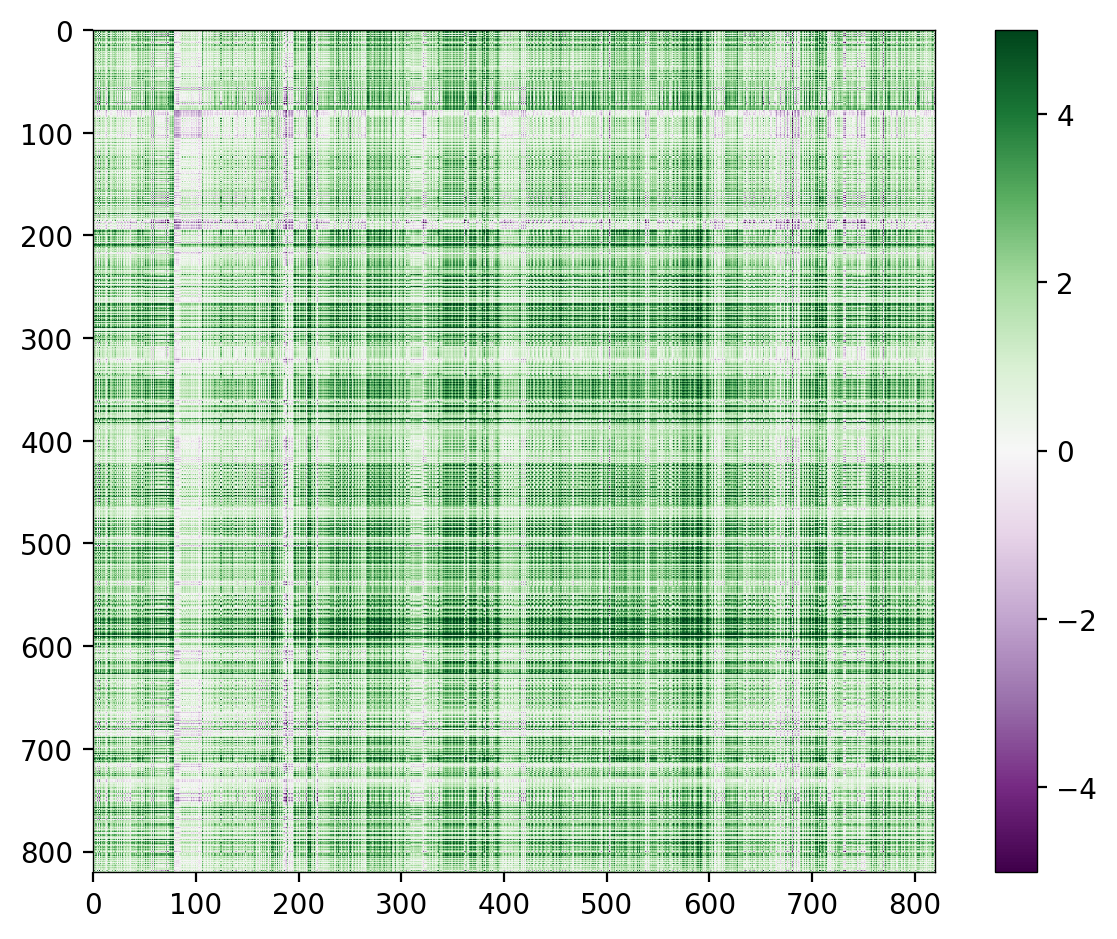

In [12]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions, vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions, vmin=-5, vmax=5,cmap='PRGn',interpolation='None')

plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/SINC_GDAC_all_effectors_matrix_{mode}.pdf')

In [13]:
import pandas as pd

In [14]:
#all_cross_interactions
all_atr_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_atr_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [15]:
#all_cross_interactions
all_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [16]:
#all_atr_interactions
all_df = pd.DataFrame(all_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(all_df)

,IDR1,IDR2,E_value
0,HopX1a_N-terminal_1_1_80,HopX1a_N-terminal_1_1_80,3.790395
1,HopX1a_N-terminal_1_1_80,HopX1a_Middle_1_200_247,2.613458
2,HopX1a_N-terminal_1_1_80,HopX1a_C-terminal_1_298_377,3.844718
3,HopX1a_N-terminal_1_1_80,HopX1c_N-terminal_1_1_80,3.180637
4,HopX1a_N-terminal_1_1_80,HopX1c_Middle_1_212_267,1.629701
...,...,...,...
672395,P93002_C-terminal_1_557_593,HopZ5b_C-terminal_1_283_346,1.567833
672396,P93002_C-terminal_1_557_593,AvrB1b_N-terminal_1_1_31,2.196364
672397,P93002_C-terminal_1_557_593,F4KG14_N-terminal_1_1_41,1.698044
672398,P93002_C-terminal_1_557_593,F4KG14_middle_1_949_1022,-0.448443


In [17]:
sorted_df_ascending = all_df.sort_values(by='E_value', ascending=True)

print("\nDataFrame sorted by 'price' (smallest to largest):")
display(sorted_df_ascending)


DataFrame sorted by 'price' (smallest to largest):


,IDR1,IDR2,E_value
154840,HopBL1b_Middle_1_412_491,HopAS1f_C-terminal_1_341_377,-10.033514
153200,HopBL1a_Middle_2_482_553,HopAS1f_C-terminal_1_341_377,-9.438213
154662,HopBL1b_Middle_1_412_491,HopM1s_C-terminal_1_801_836,-8.890329
153022,HopBL1a_Middle_2_482_553,HopM1s_C-terminal_1_801_836,-8.723607
134340,HopAR1b_N-terminal_2_81_160,HopAS1f_C-terminal_1_341_377,-8.634144
...,...,...,...
513910,HopAA1i_C-terminal_4_362_441,AvrE1x_Middle_1_779_846,8.075918
478643,AvrE1q_IDP_1_1_80,AvrE1q_IDP_1_1_80,8.148415
372043,AvrE1a_N-terminal_1_1_80,AvrE1q_IDP_1_1_80,8.168007
478513,AvrE1q_IDP_1_1_80,AvrE1a_N-terminal_1_1_80,8.168007


In [31]:
###SINC_GDAC

# Define the word to search for
#search_word = ''
# Define the words to search for
search_words = ['P93002', 'F4KG14'] # Example with two words

# Create a regex pattern to search for either word
pattern = '|'.join(search_words)
# Filter the DataFrame

df1 = sorted_df_ascending[sorted_df_ascending['IDR1'].str.contains(pattern, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
671440,F4KG14_middle_1_949_1022,HopAS1f_C-terminal_1_341_377,-7.737265
671262,F4KG14_middle_1_949_1022,HopM1s_C-terminal_1_801_836,-6.412253
671528,F4KG14_middle_1_949_1022,HopM1l_C-terminal_1_264_294,-5.281763
671491,F4KG14_middle_1_949_1022,HopD2h_C-terminal_1_157_187,-4.658022
670832,F4KG14_middle_1_949_1022,HopI1p_C-terminal_1_178_257,-4.035112
671490,F4KG14_middle_1_949_1022,HopD2e_C-terminal_1_152_185,-3.447062
671507,F4KG14_middle_1_949_1022,HopI1m_Middle_1_177_256,-3.418334
670830,F4KG14_middle_1_949_1022,HopI1h_C-terminal_1_178_257,-3.332426
670833,F4KG14_middle_1_949_1022,HopI1p_C-terminal_2_258_308,-3.251236
671510,F4KG14_middle_1_949_1022,HopI1s_Middle_1_179_258,-3.020245


In [23]:
# Define the words to search for
search_words = ['P93002', 'F4KG14']  # Example with two words

# Create a regex pattern to search for either word
pattern = '|'.join(search_words)

# Filter the DataFrame to get rows WITHOUT the search words
df1 = df1[~df1['IDR2'].str.contains(pattern, case=False, na=False)]

display(df1[0:30])

,IDR1,IDR2,E_value
671440,F4KG14_middle_1_949_1022,HopAS1f_C-terminal_1_341_377,-7.737265
671262,F4KG14_middle_1_949_1022,HopM1s_C-terminal_1_801_836,-6.412253
671528,F4KG14_middle_1_949_1022,HopM1l_C-terminal_1_264_294,-5.281763
671491,F4KG14_middle_1_949_1022,HopD2h_C-terminal_1_157_187,-4.658022
670832,F4KG14_middle_1_949_1022,HopI1p_C-terminal_1_178_257,-4.035112
671490,F4KG14_middle_1_949_1022,HopD2e_C-terminal_1_152_185,-3.447062
671507,F4KG14_middle_1_949_1022,HopI1m_Middle_1_177_256,-3.418334
670830,F4KG14_middle_1_949_1022,HopI1h_C-terminal_1_178_257,-3.332426
670833,F4KG14_middle_1_949_1022,HopI1p_C-terminal_2_258_308,-3.251236
671510,F4KG14_middle_1_949_1022,HopI1s_Middle_1_179_258,-3.020245


In [32]:
search_word = 'F4KG14'

# Filter the DataFrame
df1 = df1[df1['IDR1'].str.contains(search_word, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
671440,F4KG14_middle_1_949_1022,HopAS1f_C-terminal_1_341_377,-7.737265
671262,F4KG14_middle_1_949_1022,HopM1s_C-terminal_1_801_836,-6.412253
671528,F4KG14_middle_1_949_1022,HopM1l_C-terminal_1_264_294,-5.281763
671491,F4KG14_middle_1_949_1022,HopD2h_C-terminal_1_157_187,-4.658022
670832,F4KG14_middle_1_949_1022,HopI1p_C-terminal_1_178_257,-4.035112
671490,F4KG14_middle_1_949_1022,HopD2e_C-terminal_1_152_185,-3.447062
671507,F4KG14_middle_1_949_1022,HopI1m_Middle_1_177_256,-3.418334
670830,F4KG14_middle_1_949_1022,HopI1h_C-terminal_1_178_257,-3.332426
670833,F4KG14_middle_1_949_1022,HopI1p_C-terminal_2_258_308,-3.251236
671510,F4KG14_middle_1_949_1022,HopI1s_Middle_1_179_258,-3.020245


In [25]:
df1[0:10].to_csv("/home/wenyuantong/Desktop/data/GBPL3_effector_top_10.csv", index=True)

In [27]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/combined.fasta')
#27977

In [28]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/HEM1_domain_all_cut.tsv', skip_bad=True, safe=False)

In [29]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 30
UPPER = 80
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 821 IDRs; this will be 674041 epsilon calculations


In [30]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)



  0%|          | 0/821 [00:00<?, ?it/s]

In [33]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [34]:
#all_cross_interactions
all_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [35]:
#all_atr_interactions
all_df = pd.DataFrame(all_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(all_df)

,IDR1,IDR2,E_value
0,HopX1a_N-terminal_1_1_80,HopX1a_N-terminal_1_1_80,3.790395
1,HopX1a_N-terminal_1_1_80,HopX1a_Middle_1_200_247,2.613458
2,HopX1a_N-terminal_1_1_80,HopX1a_C-terminal_1_298_377,3.844718
3,HopX1a_N-terminal_1_1_80,HopX1c_N-terminal_1_1_80,3.180637
4,HopX1a_N-terminal_1_1_80,HopX1c_Middle_1_212_267,1.629701
...,...,...,...
674036,Q5S2C4_C-terminal_2_1368_1425,AvrB1b_N-terminal_1_1_31,1.353771
674037,Q5S2C4_C-terminal_2_1368_1425,Q5S2C4_N-terminal_1_1_60,-1.554336
674038,Q5S2C4_C-terminal_2_1368_1425,Q5S2C4_middle_1_767_805,0.008130
674039,Q5S2C4_C-terminal_2_1368_1425,Q5S2C4_C-terminal_1_1288_1367,-0.802259


In [36]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 9.41%
Percentage of pairs that are repulsive: 90.59%


In [37]:
sorted_df_ascending = all_df.sort_values(by='E_value', ascending=True)

print("\nDataFrame sorted by 'price' (smallest to largest):")
display(sorted_df_ascending)


DataFrame sorted by 'price' (smallest to largest):


,IDR1,IDR2,E_value
155028,HopBL1b_Middle_1_412_491,HopAS1f_C-terminal_1_341_377,-10.033514
153386,HopBL1a_Middle_2_482_553,HopAS1f_C-terminal_1_341_377,-9.438213
154850,HopBL1b_Middle_1_412_491,HopM1s_C-terminal_1_801_836,-8.890329
153208,HopBL1a_Middle_2_482_553,HopM1s_C-terminal_1_801_836,-8.723607
134503,HopAR1b_N-terminal_2_81_160,HopAS1f_C-terminal_1_341_377,-8.634144
...,...,...,...
514536,HopAA1i_C-terminal_4_362_441,AvrE1x_Middle_1_779_846,8.075918
479226,AvrE1q_IDP_1_1_80,AvrE1q_IDP_1_1_80,8.148415
372496,AvrE1a_N-terminal_1_1_80,AvrE1q_IDP_1_1_80,8.168007
479096,AvrE1q_IDP_1_1_80,AvrE1a_N-terminal_1_1_80,8.168007


In [41]:
print("\nDataFrame sorted by 'price' (smallest to largest):")
display(sorted_df_ascending[0:30])


DataFrame sorted by 'price' (smallest to largest):


,IDR1,IDR2,E_value
155028,HopBL1b_Middle_1_412_491,HopAS1f_C-terminal_1_341_377,-10.033514
153386,HopBL1a_Middle_2_482_553,HopAS1f_C-terminal_1_341_377,-9.438213
154850,HopBL1b_Middle_1_412_491,HopM1s_C-terminal_1_801_836,-8.890329
153208,HopBL1a_Middle_2_482_553,HopM1s_C-terminal_1_801_836,-8.723607
134503,HopAR1b_N-terminal_2_81_160,HopAS1f_C-terminal_1_341_377,-8.634144
155116,HopBL1b_Middle_1_412_491,HopM1l_C-terminal_1_264_294,-8.065016
134325,HopAR1b_N-terminal_2_81_160,HopM1s_C-terminal_1_801_836,-7.587687
657480,HopX1j_IDP_3_161_240,HopAS1f_C-terminal_1_341_377,-7.057550
11353,HopX1e_N-terminal_3_161_240,HopAS1f_C-terminal_1_341_377,-7.022278
153474,HopBL1a_Middle_2_482_553,HopM1l_C-terminal_1_264_294,-6.727395


In [38]:
# Define the word to search for
search_word = 'Q5S2C4'

# Filter the DataFrame
df1 = sorted_df_ascending[sorted_df_ascending['IDR1'].str.contains(search_word, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
673408,Q5S2C4_C-terminal_2_1368_1425,HopBL1b_Middle_1_412_491,-4.217341
673226,Q5S2C4_C-terminal_2_1368_1425,HopX1b_Middle_1_205_249,-3.746950
673438,Q5S2C4_C-terminal_2_1368_1425,AvrB2g_N-terminal_2_81_111,-3.653700
673079,Q5S2C4_C-terminal_1_1288_1367,HopAS1f_C-terminal_1_341_377,-3.601567
673406,Q5S2C4_C-terminal_2_1368_1425,HopBL1a_Middle_2_482_553,-3.591285
671437,Q5S2C4_N-terminal_1_1_60,HopAS1f_C-terminal_1_341_377,-3.575167
673872,Q5S2C4_C-terminal_2_1368_1425,HopAB1q_Middle_1_465_518,-3.048729
673383,Q5S2C4_C-terminal_2_1368_1425,HopAR1b_N-terminal_2_81_160,-2.840638
673368,Q5S2C4_C-terminal_2_1368_1425,HopAB1n_Middle_1_427_466,-2.837170
673224,Q5S2C4_C-terminal_2_1368_1425,HopX1c_Middle_1_212_267,-2.738048


In [39]:
# Define the word to search for
search_word = 'Q5S2C4'

# Filter the DataFrame
df1 = df1[~df1['IDR2'].str.contains(search_word, case=False, na=False)]

In [40]:
display(df1[0:30])

,IDR1,IDR2,E_value
673408,Q5S2C4_C-terminal_2_1368_1425,HopBL1b_Middle_1_412_491,-4.217341
673226,Q5S2C4_C-terminal_2_1368_1425,HopX1b_Middle_1_205_249,-3.746950
673438,Q5S2C4_C-terminal_2_1368_1425,AvrB2g_N-terminal_2_81_111,-3.653700
673079,Q5S2C4_C-terminal_1_1288_1367,HopAS1f_C-terminal_1_341_377,-3.601567
673406,Q5S2C4_C-terminal_2_1368_1425,HopBL1a_Middle_2_482_553,-3.591285
671437,Q5S2C4_N-terminal_1_1_60,HopAS1f_C-terminal_1_341_377,-3.575167
673872,Q5S2C4_C-terminal_2_1368_1425,HopAB1q_Middle_1_465_518,-3.048729
673383,Q5S2C4_C-terminal_2_1368_1425,HopAR1b_N-terminal_2_81_160,-2.840638
673368,Q5S2C4_C-terminal_2_1368_1425,HopAB1n_Middle_1_427_466,-2.837170
673224,Q5S2C4_C-terminal_2_1368_1425,HopX1c_Middle_1_212_267,-2.738048


In [42]:
df1[0:10].to_csv("/home/wenyuantong/Desktop/data/HEM1_effector_top_10.csv", index=True)